In [14]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

In [15]:
def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []

    imgs = torch.Tensor(52, 3, 32, 32)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE

    while k < 52 and iters < max_iters:

        try:
            images, targets = next(iterator)
        except StopIteration:
            break

        logits = model(images.to(device))

        predictions = torch.nn.functional.softmax(logits, dim=1)\
                        .cpu().detach().numpy()

        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < 52:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = images[i]
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)




def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model'):

    history = {
        'accuracy': [],
        'val_acc': [],
        'val_loss': [],
        'loss': []
    }

    best_val_loss = np.inf

    for epoch in range(epochs):

        model.train()
        start_time = time.time()

        correct = 0
        running_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader, 0):

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()

        with torch.no_grad():

            v_correct = 0
            val_loss = 0.0

            for i, t in val_loader:
                i = i.to(device)
                t = t.to(device)

                o = model(i)
                _, p = torch.max(o, 1)

                val_loss += loss_fn(o, t).item() * t.size(0)
                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)

        stop_time = time.time()

        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; '
              f'Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; '
              f'Elapsed time: {(stop_time - start_time):0.4f}')

        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)   # FIX

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
            }, f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Finished Training')

    return history



def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = torch.nn.BatchNorm2d(128)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.dropout = torch.nn.Dropout(p=0.5)

        # GAP -> 128 canais
        self.fc1 = torch.nn.Linear(128, num_classes)

    def forward(self, x):

        # input = (bs, 3, 32, 32)

        x = self.conv1(x)       # -> (bs, 32, 32, 32)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)       # -> (bs, 64, 32, 32)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.maxpool1(x)    # -> (bs, 64, 16, 16)

        x = self.conv3(x)       # -> (bs, 128, 16, 16)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)       # -> (bs, 128, 16, 16)
        x = self.bn4(x)
        x = self.relu4(x)

        x = self.maxpool2(x)    # -> (bs, 128, 8, 8)

        # Global Average Pooling
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 128)

        x = self.dropout(x)

        x = self.fc1(x)

        return x

class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False

In [16]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'C:/Users/Rodrigo/Desktop/VCPI-2526'  ## CHANGE THIS TO YOUR OWN PATH

PATH_TRAINING_SET = f'{BASE_PATH}/train_images'
PATH_TEST_SET = f'{BASE_PATH}/test_images'

BATCH_SIZE = 32
EPOCHS = 30
RUNS = 1

cuda:0


In [17]:
transform = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

full_train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform
)

train_size = int(0.8 * len(full_train_set))
val_size = len(full_train_set) - train_size

train_set, val_set = torch.utils.data.random_split(
    full_train_set,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_set = torchvision.datasets.ImageFolder(
    root=PATH_TEST_SET,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
transform_aug = v2.Compose([
    v2.Resize((32, 32)),

    v2.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.2,
        hue=0.1
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [6]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'weights/dynamic_colorJitter_aug_I_{i}')

Epoch: 000; Loss: 2.522994; Accuracy: 28.0901; Val Loss: 1.685959; Val Acc: 47.9208; Elapsed time: 33.5471
Epoch: 001; Loss: 1.237599; Accuracy: 63.7706; Val Loss: 0.584838; Val Acc: 82.0933; Elapsed time: 32.9460
Epoch: 002; Loss: 0.540294; Accuracy: 85.8743; Val Loss: 0.306415; Val Acc: 91.2447; Elapsed time: 31.5077
Epoch: 003; Loss: 0.281705; Accuracy: 93.3007; Val Loss: 0.074763; Val Acc: 98.6421; Elapsed time: 31.4039
Epoch: 004; Loss: 0.181342; Accuracy: 95.7960; Val Loss: 0.027348; Val Acc: 99.8020; Elapsed time: 31.7726
Epoch: 005; Loss: 0.134466; Accuracy: 96.7720; Val Loss: 0.018304; Val Acc: 99.7313; Elapsed time: 31.3528
Epoch: 006; Loss: 0.116470; Accuracy: 97.1454; Val Loss: 0.019848; Val Acc: 99.7878; Elapsed time: 31.3832
Epoch: 007; Loss: 0.090356; Accuracy: 97.7735; Val Loss: 0.038653; Val Acc: 98.7553; Elapsed time: 31.6390
Epoch: 008; Loss: 0.078099; Accuracy: 98.1300; Val Loss: 0.005599; Val Acc: 99.9859; Elapsed time: 31.7129
Epoch: 009; Loss: 0.071633; Accuracy:

In [19]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'weights/dynamic_colorJitter_aug_I_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

27 0.9866983294487 1.0
0.9866983294487


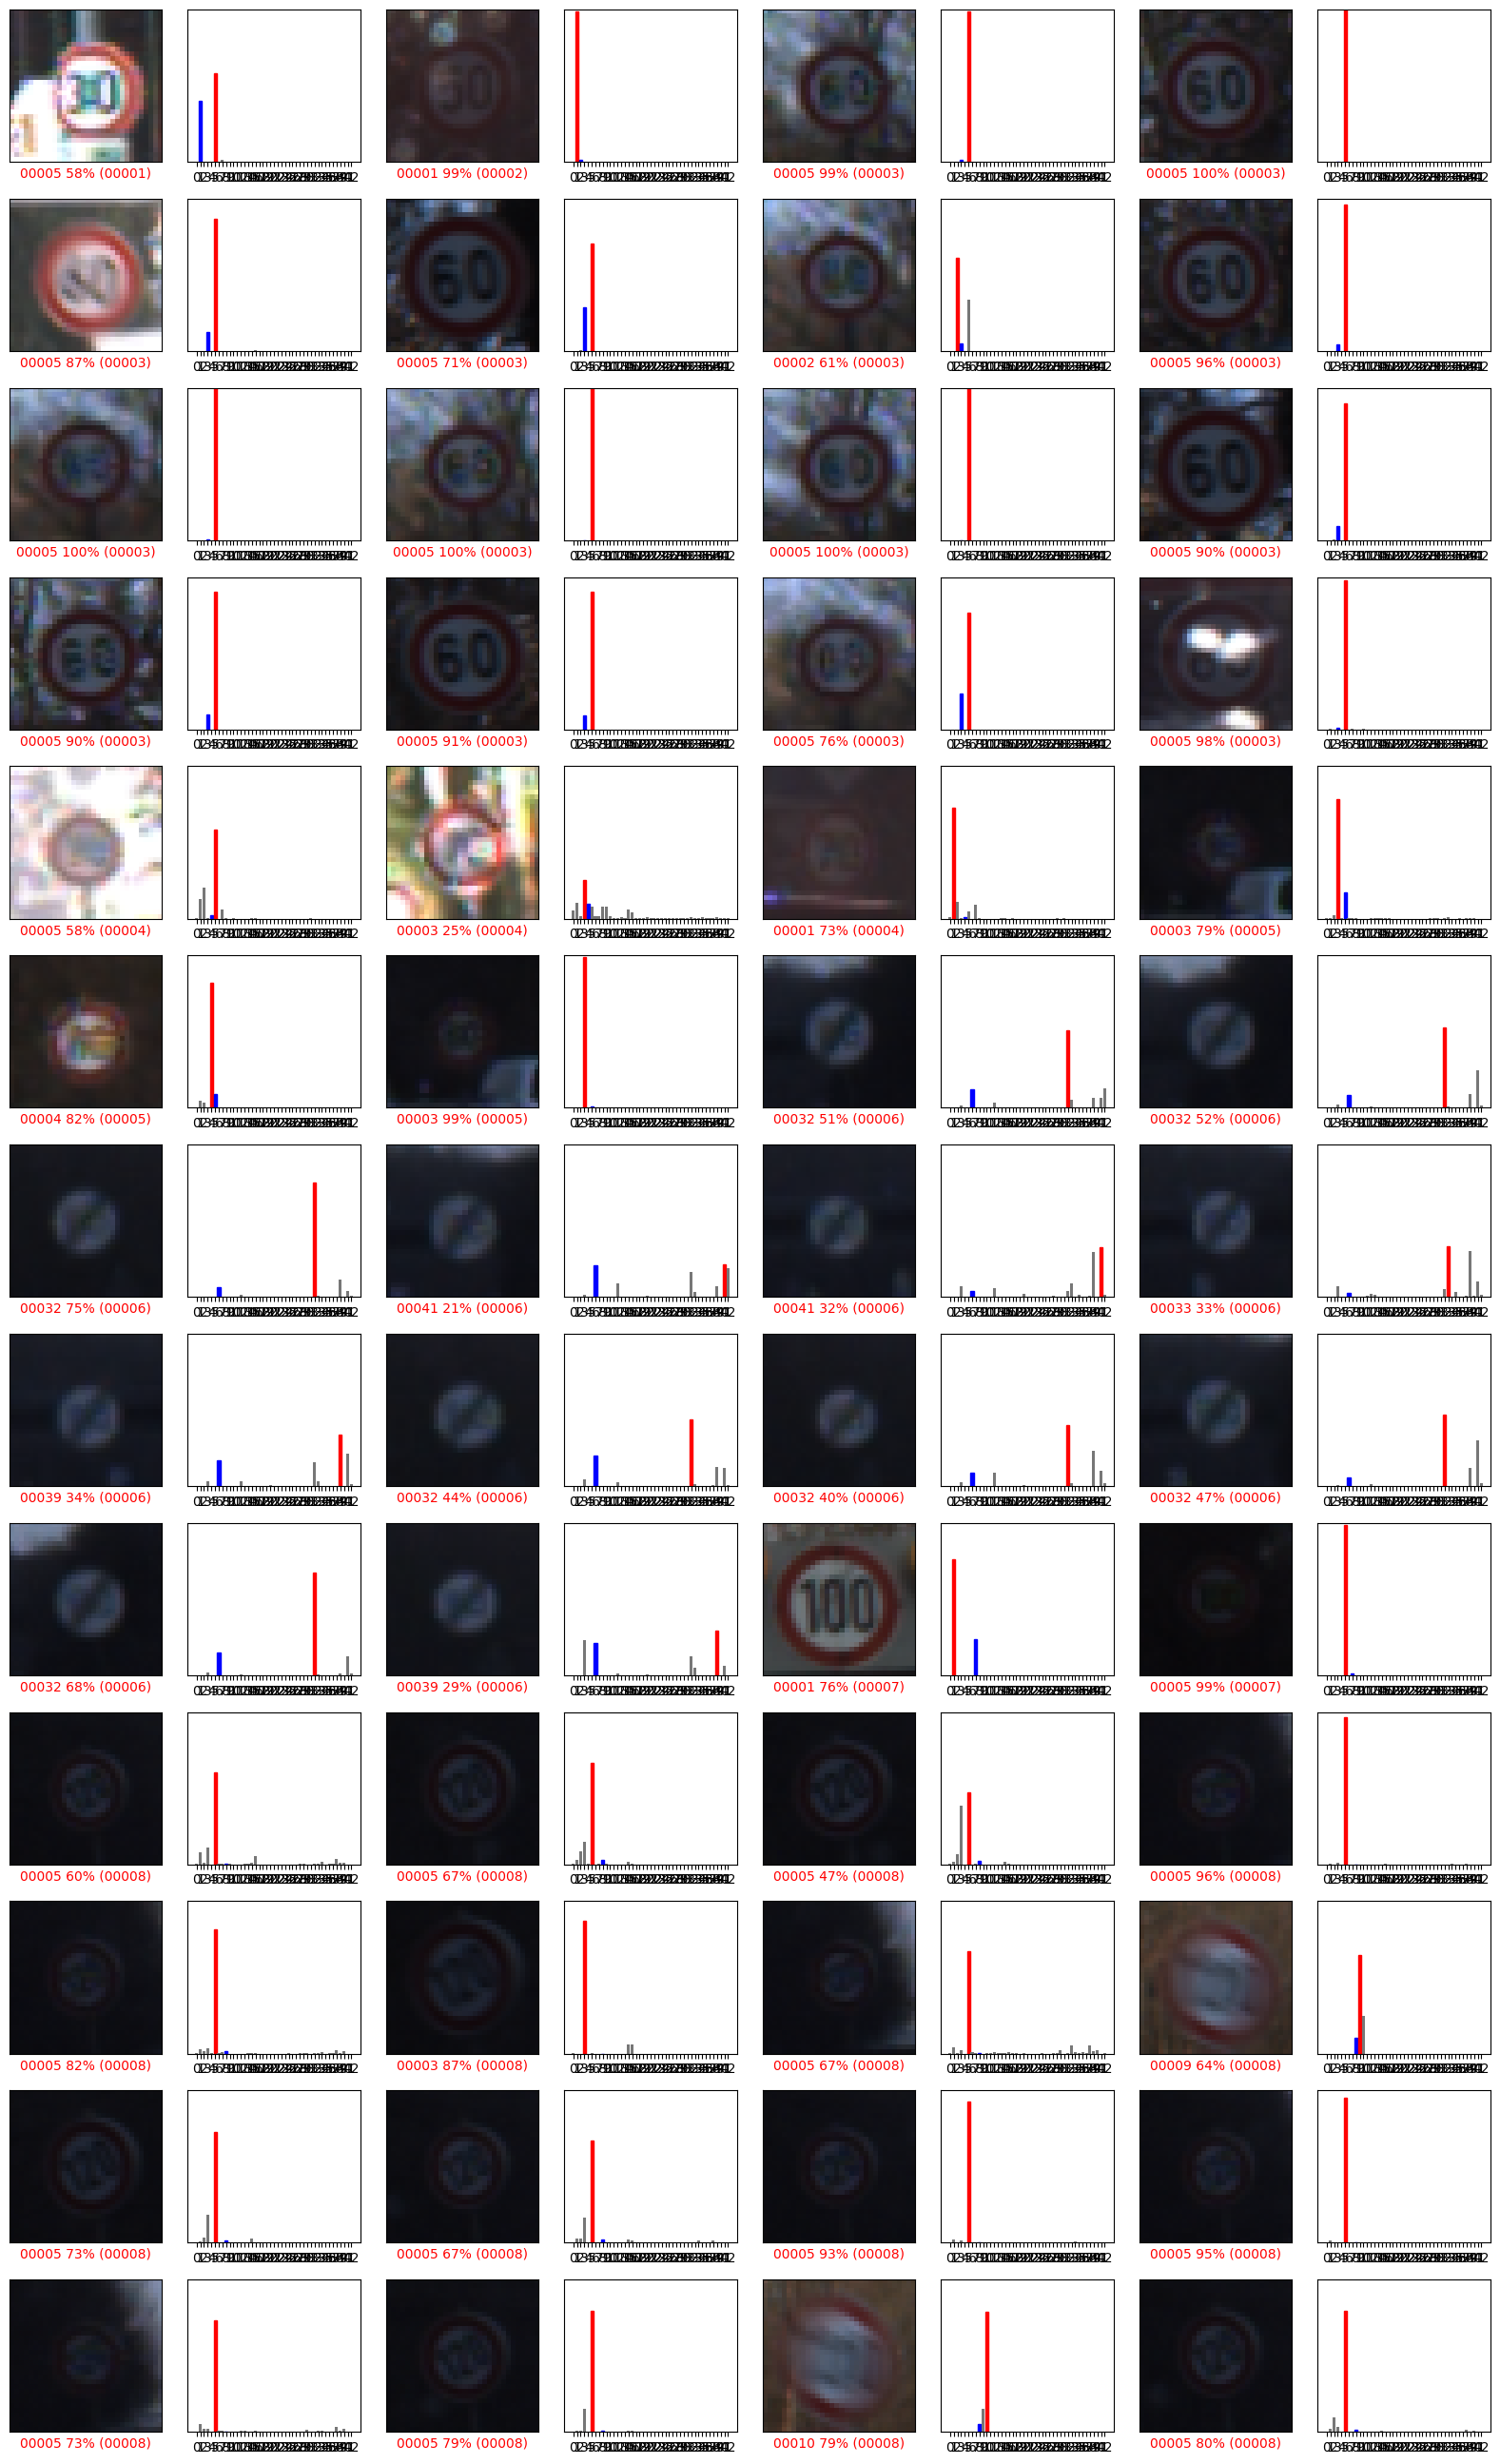

In [20]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

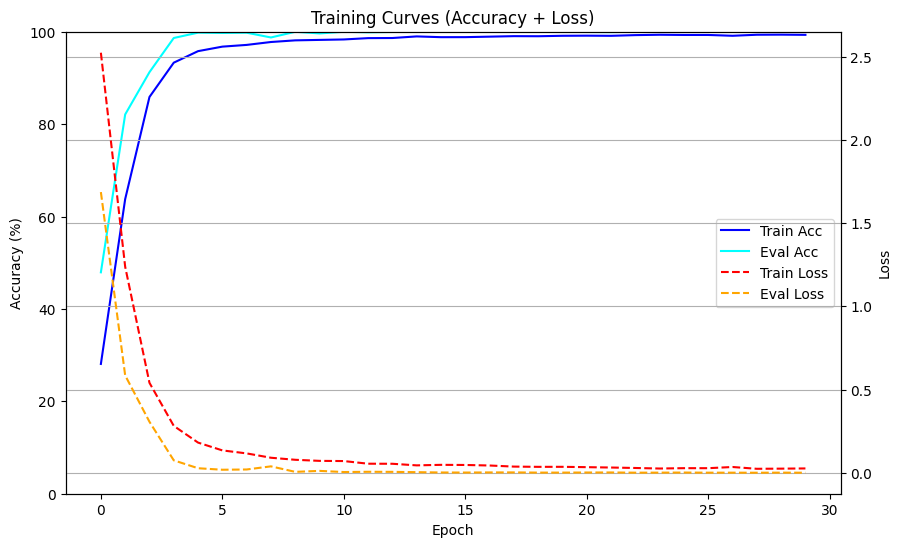

Epoch: 27 | Test Acc: 98.67% | Val Acc: 100.00%


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(history_II)

# garantir tipos numéricos
df = df.astype({
    'accuracy': float,
    'val_acc': float,
    'loss': float,
    'val_loss': float
})

# renomear para clareza
df.rename(columns={
    'accuracy': 'train_acc',
    'val_acc': 'eval_acc',
    'loss': 'train_loss',
    'val_loss': 'eval_loss'
}, inplace=True)

# -------------------------
# PLOT ÚNICO (duplo eixo)
# -------------------------
fig, ax1 = plt.subplots(figsize=(10,6))

# Accuracy (eixo esquerdo)
ax1.plot(df['train_acc'], label='Train Acc', color='blue')
ax1.plot(df['eval_acc'], label='Eval Acc', color='cyan')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)

# Loss (eixo direito)
ax2 = ax1.twinx()
ax2.plot(df['train_loss'], label='Train Loss', color='red', linestyle='--')
ax2.plot(df['eval_loss'], label='Eval Loss', color='orange', linestyle='--')
ax2.set_ylabel('Loss')

# títulos e layout
plt.title('Training Curves (Accuracy + Loss)')
ax1.set_xlabel('Epoch')

# juntar legendas dos dois eixos
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.grid(True)
plt.show()

print(
    f'Epoch: {reload["epoch"]} | '
    f'Test Acc: {eval*100:.2f}% | '
    f'Val Acc: {eval_val*100:.2f}%'
)

acc_colorJitter = eval

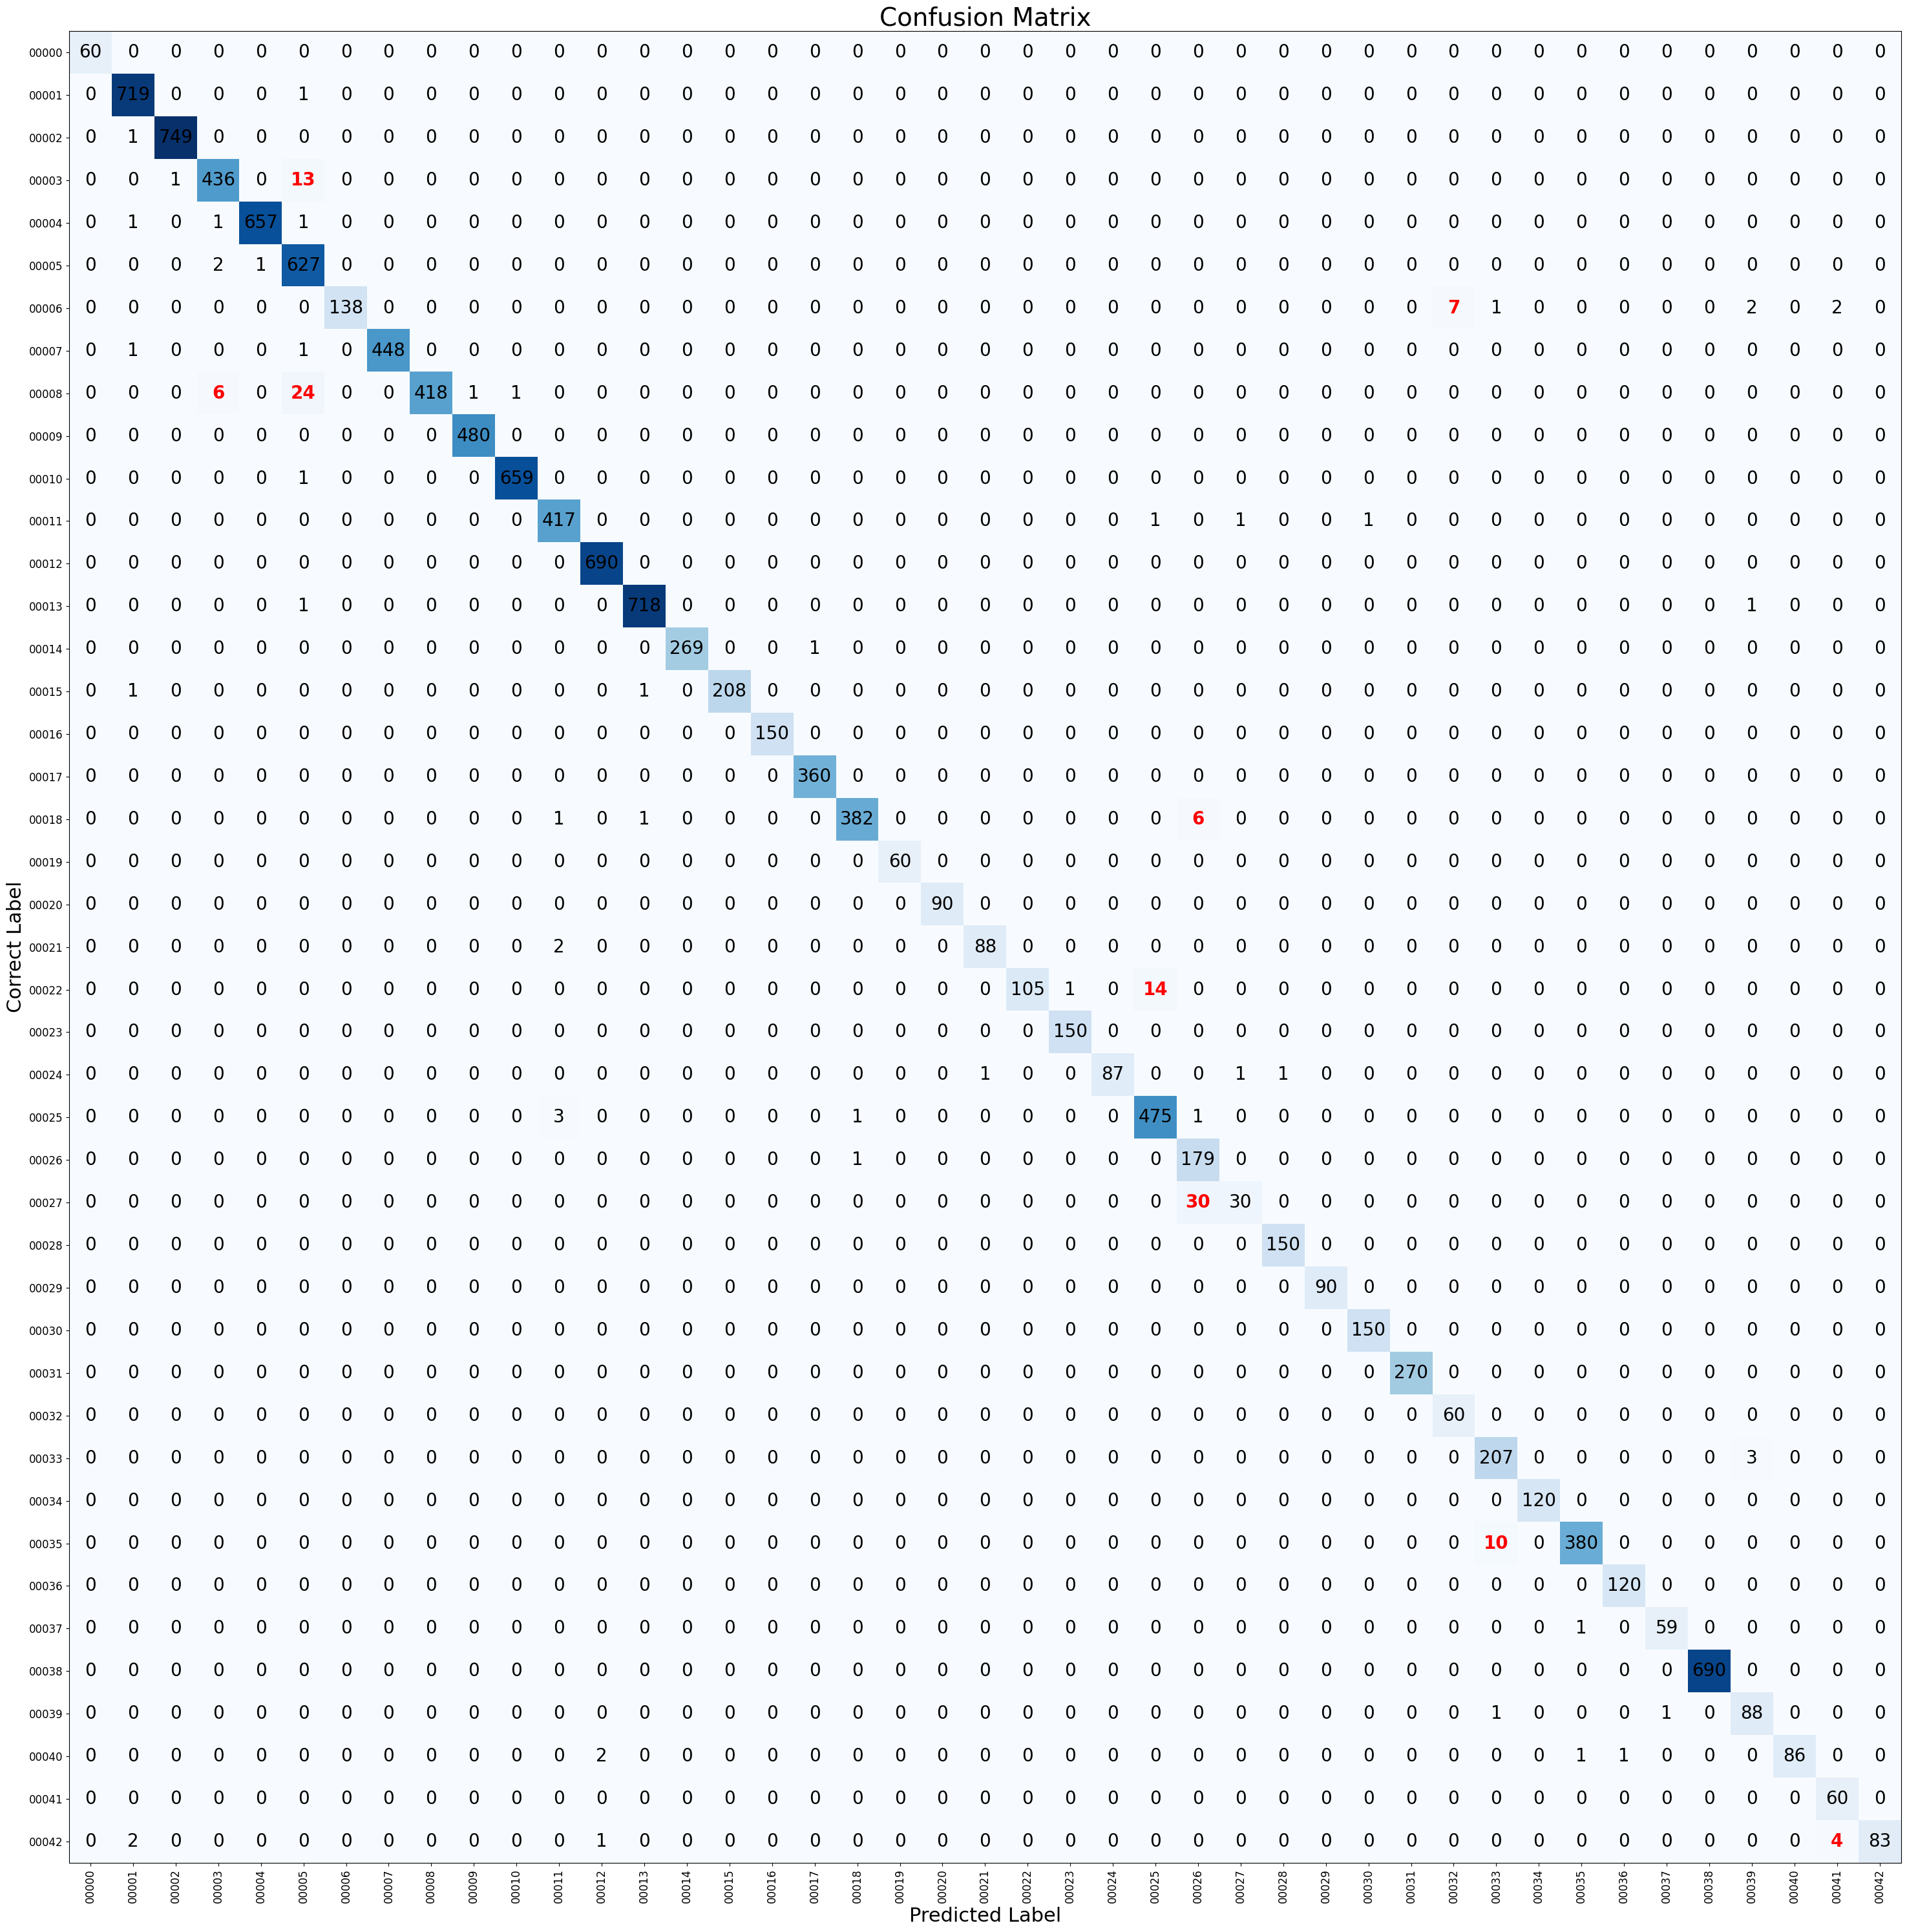

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_highlight(model, data_loader, classes, threshold=3):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in data_loader:

            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    cm = confusion_matrix(all_targets, all_preds)

    fig, ax = plt.subplots(figsize=(30, 30))

    im = ax.imshow(cm, cmap='Blues')

    # ticks
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(classes, rotation=90, fontsize=12)
    ax.set_yticklabels(classes, fontsize=12)

    # axis labels
    ax.set_xlabel("Predicted Label", fontsize=22)
    ax.set_ylabel("Correct Label", fontsize=22)

    # values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            value = cm[i, j]

            # highlight erros relevantes
            if i != j and value > threshold:
                color = 'red'
                weight = 'bold'
            else:
                color = 'black'
                weight = 'normal'

            ax.text(
                j,
                i,
                str(value),
                ha='center',
                va='center',
                fontsize=20,
                color=color,
                fontweight=weight
            )

    plt.title("Confusion Matrix", fontsize=28)

    plt.tight_layout()
    plt.show()


plot_confusion_matrix_highlight(
    model_Conv,
    test_loader,
    test_set.classes,
    threshold=3
)

In [26]:
# =========================================================
# RESULTADOS FINAIS
# =========================================================

# Última epoch
train_acc = history_II['accuracy'][-1]
train_loss = history_II['loss'][-1]

eval_acc = history_II['val_acc'][-1]
eval_loss = history_II['val_loss'][-1]

# Test accuracy
test_acc = evaluate(model_Conv_II, test_loader) * 100

# =========================================================
# PRINT
# =========================================================

print('\n========== FINAL RESULTS ==========')

print(f'Train Accuracy : {train_acc:.2f}%')
print(f'Train Loss     : {train_loss:.4f}')

print(f'Eval Accuracy  : {eval_acc:.2f}%')
print(f'Eval Loss      : {eval_loss:.4f}')

print(f'Test Accuracy  : {test_acc:.2f}%')


========== FINAL RESULTS ==========
Train Accuracy : 99.32%
Train Loss     : 0.0261
Eval Accuracy  : 100.00%
Eval Loss      : 0.0005
Test Accuracy  : 99.02%
